# Feature to Target Analysis

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

COLORS = {
    "primary": "steelblue",
    "success": "green",
    "failure": "red",
    "accent": "orange",
}

In [44]:
import os

modeling_dataset = "../data/processed/transfer_modeling_dataset.csv"

df = pd.read_csv(modeling_dataset, parse_dates=["transfer_date"])

print("shape:", df.shape)
print("transfers: ", len(df))
print("success count: ", df["transfer_success"].sum())
print("failure count: ", (df["transfer_success"] == 0).sum())
print(f"success rate: {df['transfer_success'].mean():.1%}")

shape: (6675, 103)
transfers:  6675
success count:  1148
failure count:  5527
success rate: 17.2%


## Transfer Success Rate Over Seasons
we examine how the rate of successful transfers evolved from 2018 to 2021

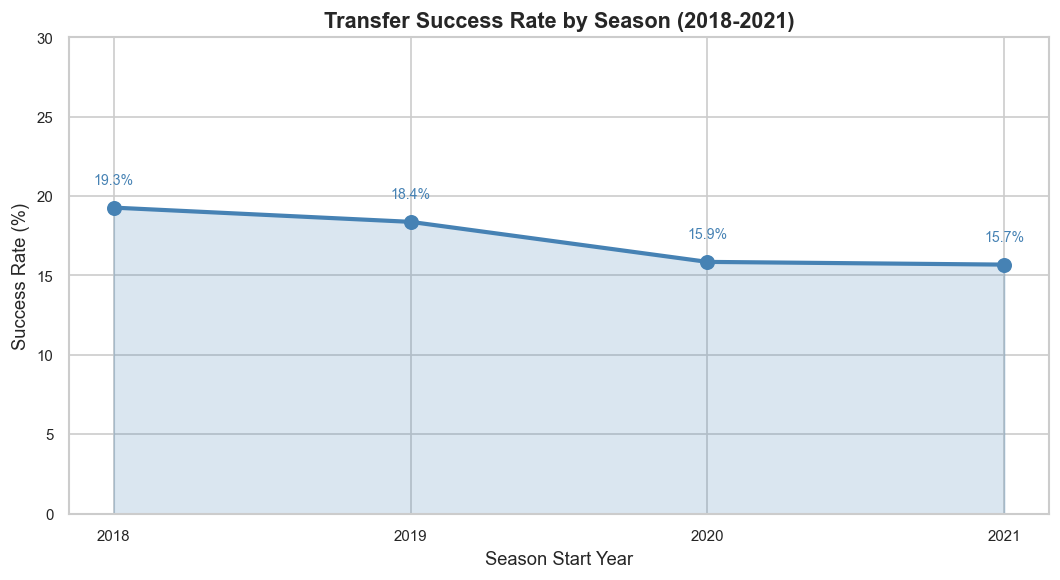

In [45]:
season_stats = (
    df[df["season_start_year"].between(2018, 2021)]
    .groupby("season_start_year")["transfer_success"]
    .agg(success_rate="mean", total="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

# area fill under the line
ax.fill_between(
    season_stats["season_start_year"],
    season_stats["success_rate"] * 100,
    alpha=0.2,
    color=COLORS["primary"]
)

# line and markers
ax.plot(
    season_stats["season_start_year"],
    season_stats["success_rate"] * 100,
    color=COLORS["primary"],
    linewidth=2.5,
    marker="o",
    markersize=8
)

# annotatation
for _, row in season_stats.iterrows():
    ax.annotate(
        f"{row['success_rate']:.1%}",
        xy=(row["season_start_year"], row["success_rate"] * 100),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=8.5,
        color=COLORS["primary"]
    )

ax.set_title("Transfer Success Rate by Season (2018-2021)", fontweight="bold")
ax.set_xlabel("Season Start Year")
ax.set_ylabel("Success Rate (%)")
ax.set_xticks(season_stats["season_start_year"])
ax.set_ylim(0, 30)

plt.tight_layout()
plt.show()

## Transfer Success Rate by Position
help us determine how often transfers succeed across the four main positions.

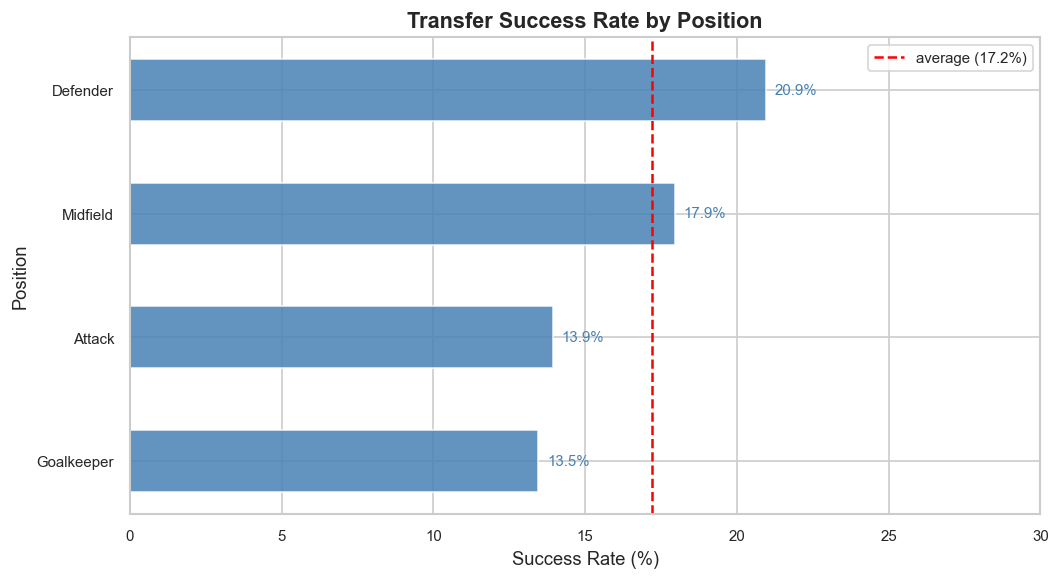

success rate by position:
  position  success_rate  total
  Defender      0.209447   2096
  Midfield      0.179459   1850
    Attack      0.139277   2075
Goalkeeper      0.134557    654


In [46]:
position_stats = (
    df.groupby("position")["transfer_success"]
    .agg(success_rate="mean", total="count")
    .reset_index()
    .sort_values("success_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    position_stats["position"],
    position_stats["success_rate"] * 100,
    color=COLORS["primary"],
    alpha=0.85,
    height=0.5
)

# annotatation
for bar, (_, row) in zip(bars, position_stats.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{row['success_rate']:.1%}",
        va="center",
        fontsize=9,
        color=COLORS["primary"]
    )

ax.set_title("Transfer Success Rate by Position", fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.set_ylabel("Position")
ax.set_xlim(0, 30)
ax.axvline(df["transfer_success"].mean() * 100, color=COLORS["failure"],
           linewidth=1.5, linestyle="--", label=f"average ({df['transfer_success'].mean():.1%})")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("success rate by position:")
print(position_stats.sort_values("success_rate", ascending=False).to_string(index=False))

## Age and Pre-Transfer Market Value by Transfer Outcome

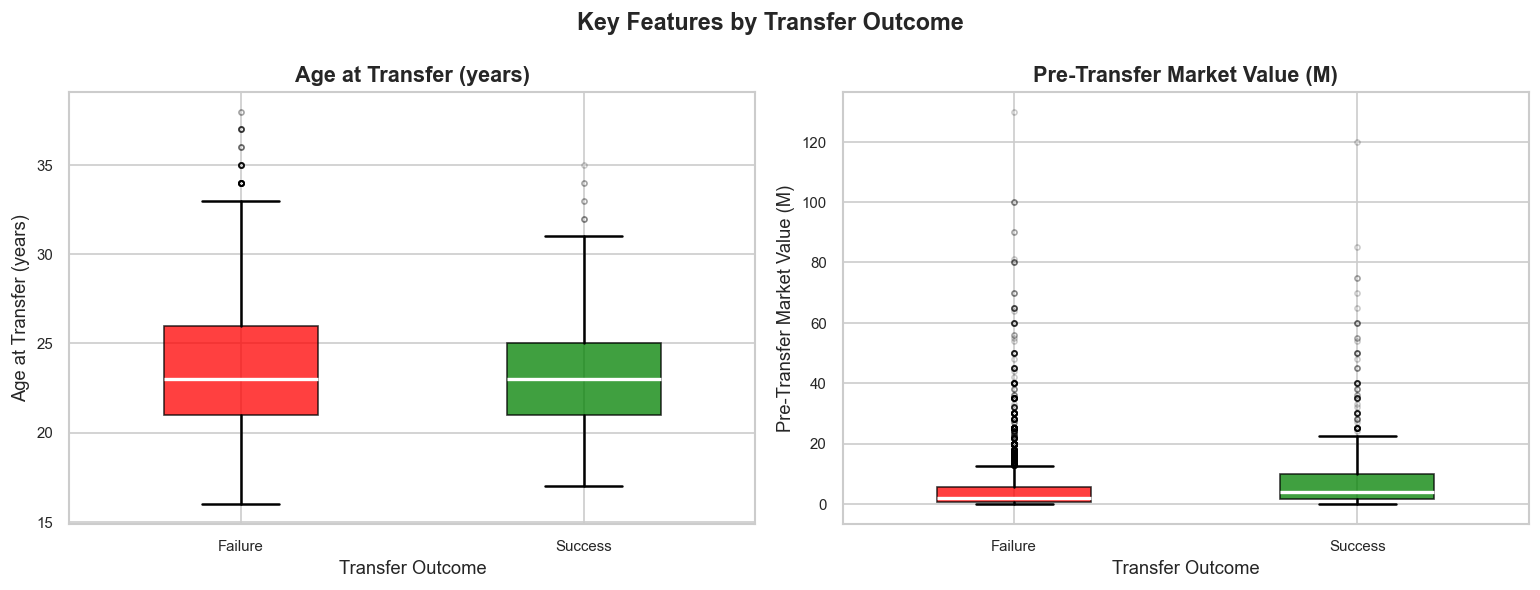

median age failure:  23.0
median age success:  23.0
median pre-value failure (M):  2.0
median pre-value success (M):  4.0


In [47]:
success_labels = {0: "Failure", 1: "Success"}
df["outcome_label"] = df["transfer_success"].map(success_labels)

# drop missing values for each feature
age_data = df[["age_at_transfer", "outcome_label"]].dropna()
value_data = df[["pre_transfer_market_value", "outcome_label"]].dropna().copy()
value_data["pre_transfer_market_value"] = value_data["pre_transfer_market_value"] / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Key Features by Transfer Outcome", fontsize=14, fontweight="bold")

box_colors = [COLORS["failure"], COLORS["success"]]

for ax, (col, label, data) in zip(axes, [
    ("age_at_transfer", "Age at Transfer (years)", age_data),
    ("pre_transfer_market_value", "Pre-Transfer Market Value (M)", value_data),
]):
    groups = [data[data["outcome_label"] == g][col].values for g in ["Failure", "Success"]]
    bp = ax.boxplot(
        groups,
        labels=["Failure", "Success"],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", alpha=0.2, markersize=3)
    )
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for flier, color in zip(bp["fliers"], box_colors):
        flier.set_color(color)

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Transfer Outcome")
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

print("median age failure: ", age_data[age_data["outcome_label"]=="Failure"]["age_at_transfer"].median())
print("median age success: ", age_data[age_data["outcome_label"]=="Success"]["age_at_transfer"].median())
print("median pre-value failure (M): ", round(value_data[value_data["outcome_label"]=="Failure"]["pre_transfer_market_value"].median(), 2))
print("median pre-value success (M): ", round(value_data[value_data["outcome_label"]=="Success"]["pre_transfer_market_value"].median(), 2))

## Feature Correlation with Transfer Success
correlation heatmap that includes the target variable directly

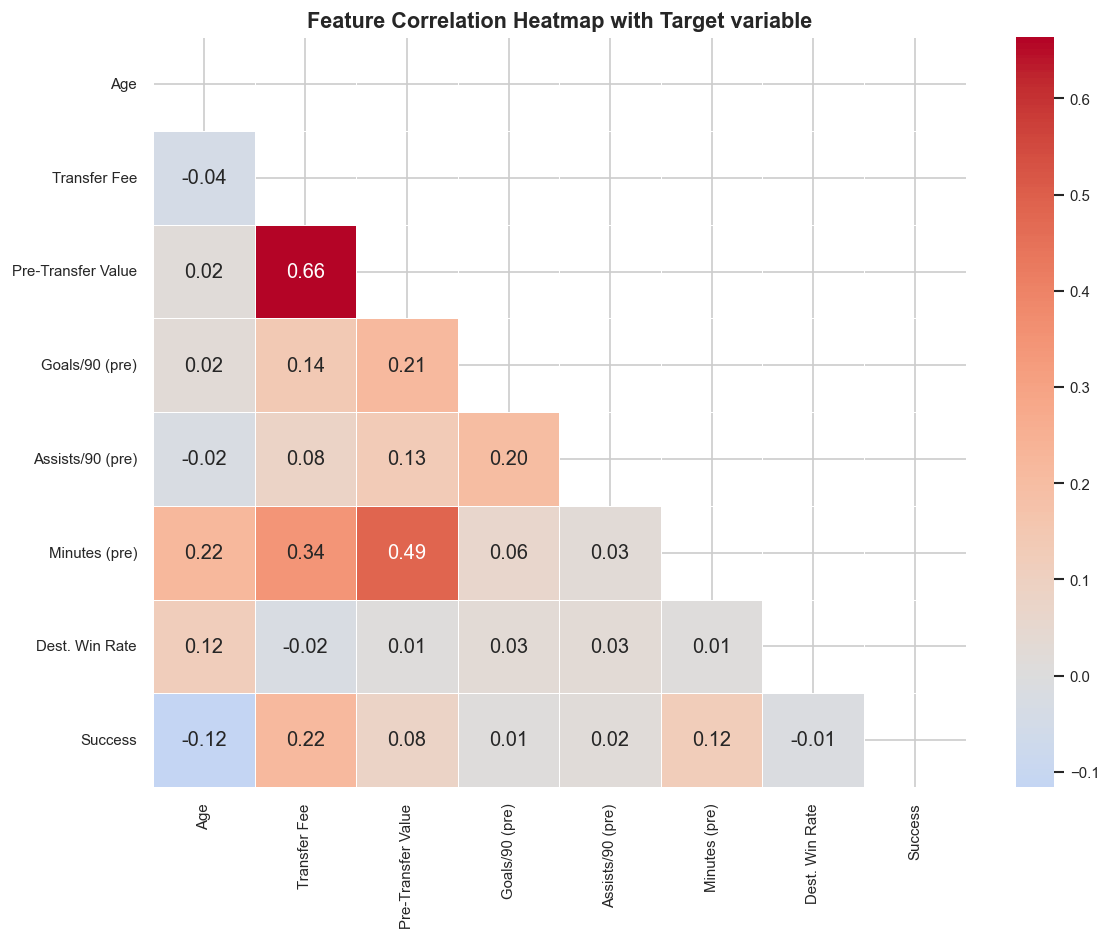

correlation with transfer_success:
Transfer Fee          0.216
Minutes (pre)         0.119
Pre-Transfer Value    0.085
Assists/90 (pre)      0.018
Goals/90 (pre)        0.006
Dest. Win Rate       -0.012
Age                  -0.116
Name: Success, dtype: float64


In [48]:
heatmap_cols = [
    "age_at_transfer",
    "transfer_fee",
    "pre_transfer_market_value",
    "player_goals_per90_365d_pre",
    "player_assists_per90_365d_pre",
    "player_minutes_365d_pre",
    "destination_win_rate_365d_pre",
    "transfer_success",
]

label_map = {
    "age_at_transfer": "Age",
    "transfer_fee": "Transfer Fee",
    "pre_transfer_market_value": "Pre-Transfer Value",
    "player_goals_per90_365d_pre": "Goals/90 (pre)",
    "player_assists_per90_365d_pre": "Assists/90 (pre)",
    "player_minutes_365d_pre": "Minutes (pre)",
    "destination_win_rate_365d_pre": "Dest. Win Rate",
    "transfer_success": "Success",
}

corr_df = df[heatmap_cols].dropna().rename(columns=label_map)
corr = corr_df.corr()

# mask upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Feature Correlation Heatmap with Target variable", fontweight="bold")

plt.tight_layout()
plt.show()

print("correlation with transfer_success:")
print(corr["Success"].drop("Success").sort_values(ascending=False).round(3))

## Dashboard

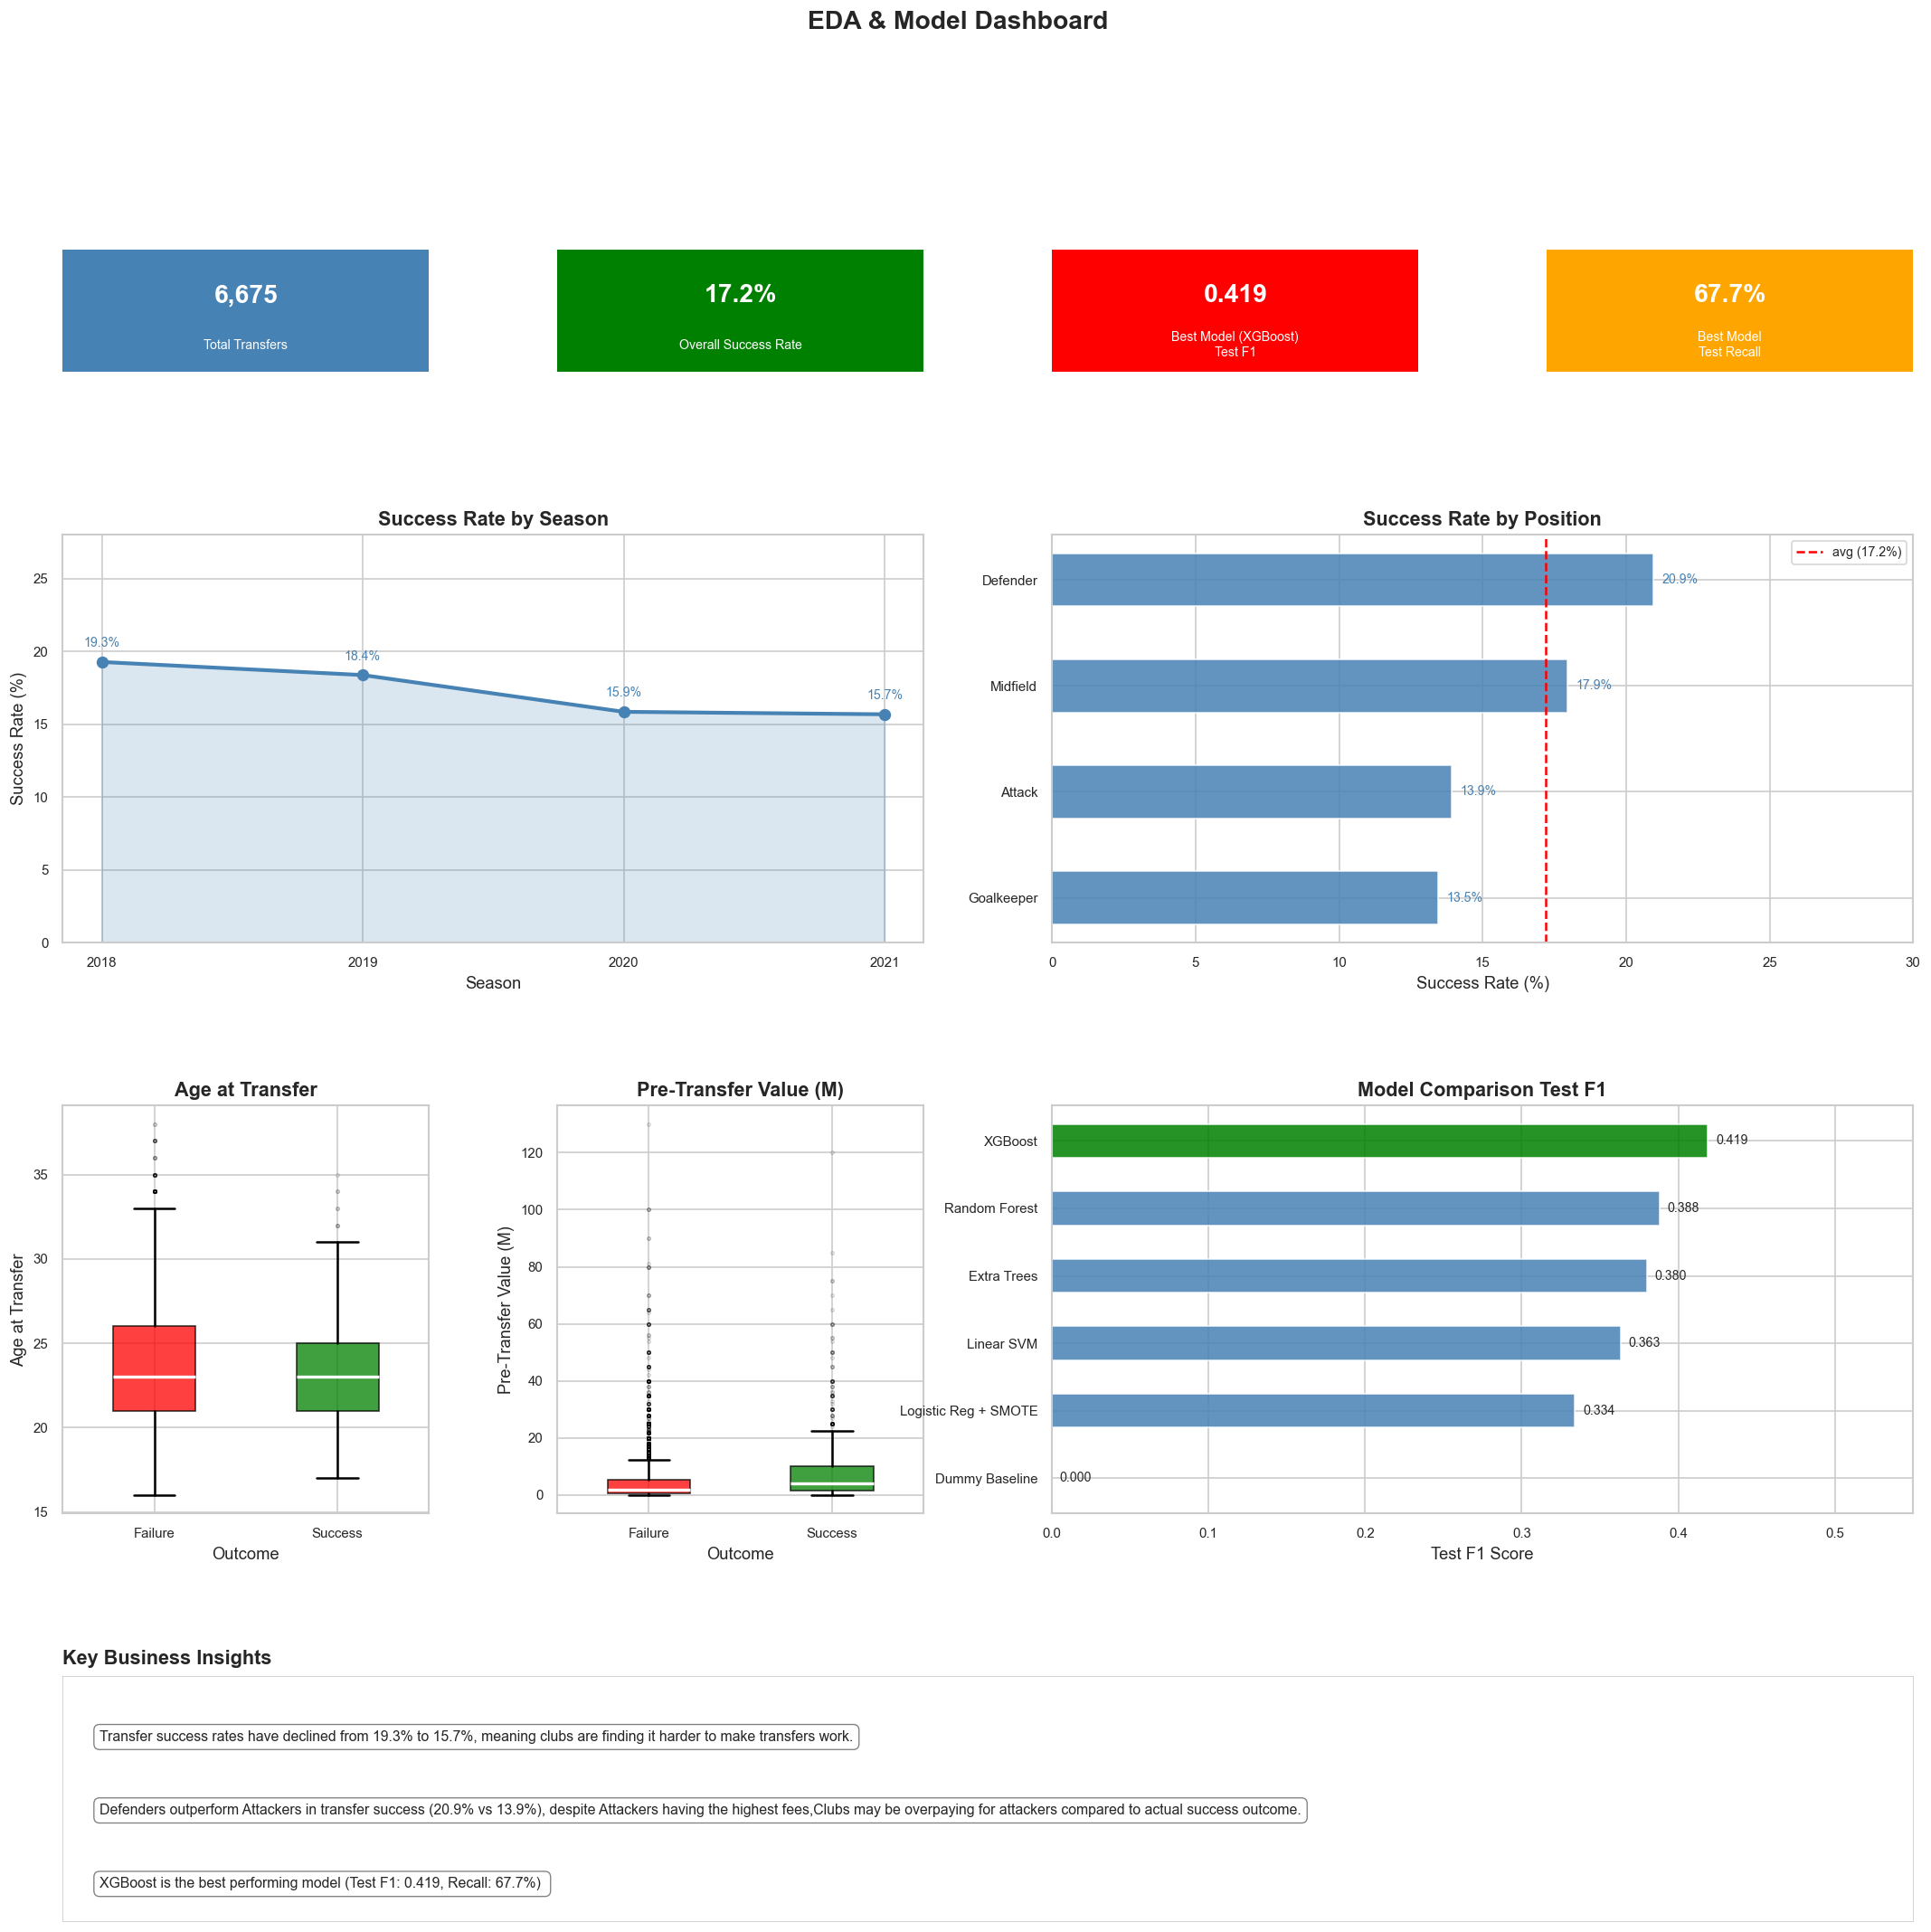

In [49]:
season_stats   = season_stats.rename(columns={"success_rate": "success_rate_col"})
position_stats = position_stats.rename(columns={"success_rate": "success_rate_col"})

fig = plt.figure(figsize=(22, 20))
fig.suptitle("EDA & Model Dashboard",
             fontsize=17, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(
    4, 4,
    figure=fig,
    hspace=0.55,
    wspace=0.35,
    height_ratios=[0.6, 2, 2, 1.2]
)

# kpi
kpis = [
    ("Total Transfers", f"{total_transfers:,}", "steelblue"),
    ("Overall Success Rate", f"{success_rate:.1%}", "green"),
    ("Best Model (XGBoost)\nTest F1", f"{best_f1:.3f}", "red"),
    ("Best Model\nTest Recall", f"{best_recall:.1%}", "orange"),
]
for col, (label, value, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, col])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.62, value, ha="center", va="center",
                fontsize=17, fontweight="bold", color="white",
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.22, label, ha="center", va="center",
                fontsize=8.5, color="white", transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)

# row 1 success rate by season
ax1 = fig.add_subplot(gs[1, :2])
ax1.fill_between(season_stats["season_start_year"],
                 season_stats["success_rate_col"] * 100, alpha=0.2, color=COLORS["primary"])
ax1.plot(season_stats["season_start_year"], season_stats["success_rate_col"] * 100,
         color=COLORS["primary"], linewidth=2.5, marker="o", markersize=7)
for _, row in season_stats.iterrows():
    ax1.annotate(f"{row['success_rate_col']:.1%}",
                 xy=(row["season_start_year"], row["success_rate_col"] * 100),
                 xytext=(0, 10), textcoords="offset points",
                 ha="center", fontsize=8.5, color=COLORS["primary"])
ax1.set_title("Success Rate by Season", fontweight="bold")
ax1.set_xlabel("Season")
ax1.set_ylabel("Success Rate (%)")
ax1.set_xticks(season_stats["season_start_year"])
ax1.set_ylim(0, 28)

# row 1 success rate by position
ax2 = fig.add_subplot(gs[1, 2:])
bars2 = ax2.barh(
    position_stats["position"],
    position_stats["success_rate_col"] * 100,
    color=COLORS["primary"], alpha=0.85, height=0.5
)
for bar, (_, row) in zip(bars2, position_stats.iterrows()):
    ax2.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{row['success_rate_col']:.1%}",
        va="center", fontsize=8.5, color=COLORS["primary"]
    )
ax2.axvline(success_rate * 100, color=COLORS["failure"],
            linewidth=1.5, linestyle="--", label=f"avg ({success_rate:.1%})")
ax2.set_title("Success Rate by Position", fontweight="bold")
ax2.set_xlabel("Success Rate (%)")
ax2.set_xlim(0, 30)
ax2.legend(fontsize=8.5)

# row 2 age box + value box + model comparison
for col_idx, (col, label, data) in enumerate([
    ("age_at_transfer", "Age at Transfer", age_data),
    ("pre_transfer_market_value", "Pre-Transfer Value (M)", value_data),
]):
    ax = fig.add_subplot(gs[2, col_idx])
    groups = [data[data["outcome_label"] == g][col].values for g in ["Failure", "Success"]]
    bp = ax.boxplot(groups, labels=["Failure", "Success"], patch_artist=True,
                    widths=0.45,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker="o", alpha=0.15, markersize=2))
    for patch, color in zip(bp["boxes"], [COLORS["failure"], COLORS["success"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for flier, color in zip(bp["fliers"], [COLORS["failure"], COLORS["success"]]):
        flier.set_color(color)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(label)

# model comparison bar chart
ax_model = fig.add_subplot(gs[2, 2:])
colors_bar = [COLORS["success"] if m == "XGBoost" else COLORS["primary"]
              for m in model_results["model"]]
bars_m = ax_model.barh(
    model_results["model"], model_results["test_f1"],
    color=colors_bar, alpha=0.85, height=0.5
)
for bar, val in zip(bars_m, model_results["test_f1"]):
    ax_model.text(bar.get_width() + 0.005,
                  bar.get_y() + bar.get_height() / 2,
                  f"{val:.3f}", va="center", fontsize=8.5)
ax_model.set_title("Model Comparison Test F1", fontweight="bold")
ax_model.set_xlabel("Test F1 Score")
ax_model.set_xlim(0, 0.55)

# row 3 business insights text panel
ax_text = fig.add_subplot(gs[3, :])
ax_text.set_facecolor("white")
ax_text.set_xticks([])
ax_text.set_yticks([])
for spine in ax_text.spines.values():
    spine.set_linewidth(0.5)

insights = [
    "Transfer success rates have declined from 19.3% to 15.7%, "
    "meaning clubs are finding it harder to make transfers work.",

    "Defenders outperform Attackers in transfer success (20.9% vs 13.9%), "
    "despite Attackers having the highest fees,"
    "Clubs may be overpaying for attackers compared to actual success outcome.",

    "XGBoost is the best performing model (Test F1: 0.419, Recall: 67.7%) ",
]
for i, text in enumerate(insights):
    ax_text.text(0.02, 0.78 - i * 0.30, text,
                 transform=ax_text.transAxes,
                 fontsize=9.5, va="top",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                           edgecolor="gray", linewidth=0.8))

ax_text.set_title("Key Business Insights", fontweight="bold", loc="left", pad=8)

plt.show()